# Toki DPD91 Prediction

## Data Scientist Candidate Assignment

Энэхүү notebook-ийн зорилго нь Toki-ийн credit card үйлчилгээний 31 хоногийн хугацаа хэтрүүлэлттэй (`DPD31`) зээлдэгч цаашид 91 хоног болон түүнээс дээш хугацаагаар хугацаа хэтрүүлэх (`DPD91+`) эсэхийг таамаглах Machine Learning model боловсруулахад оршино.

Шинжилгээг хийхдээ өгөгдлийн чанар, feature availability, Data Leakage, temporal validation, feature engineering, model selection болон final evaluation зэрэг үе шатуудыг дараалалтайгаар авч үзнэ.

Эцсийн зорилго нь зөвхөн өндөр predictive performance авах бус, тухайн model-ийн үр дүнг бизнесийн үйл ажиллагаанд хэрхэн ашиглаж болохыг тайлбарлах, мөн model-ийн хязгаарлалтыг тодорхойлох явдал юм.

## 1. Environment Setup

Энэ хэсэгт шинжилгээ болон Machine Learning model боловсруулахад шаардлагатай Python libraries-ийг импортолно.

Шинжилгээний явцад reproducibility-г хадгалахын тулд шаардлагатай тохиолдолд `random_state`-ийг тогтмол утгаар ашиглана.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading

Даалгаварт өгөгдөл Excel workbook хэлбэрээр өгөгдсөн бөгөөд workbook-ийн sheet-үүдэд credit card үйлчилгээний DPD31-тэй холбоотой мэдээлэл хадгалагдсан.

Эхний алхамд workbook-ийн бүх sheet-ийн нэр болон хэмжээтэй танилцаж, modeling-д ямар өгөгдөл ашиглахыг тодорхойлно.

Энэ шатанд өгөгдлийг шууд өөрчлөхгүй. Эхлээд эх өгөгдлийн бүтцийг шалгаж, дараагийн preprocessing алхмуудыг нотолгоонд үндэслэн тодорхойлно.

In [3]:
# Path to the provided Excel workbook
file_path = "../data/raw/Toki Data Scientist task.xlsx"

# Read workbook structure
excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
for sheet in excel_file.sheet_names:
    print(f"- {sheet}")

Available sheets:
- Rule
- data_description
- payment
- overdue
- balance
- user_list


In [4]:
# Load all sheets without modifying the original data
data_sheets = {
    sheet: pd.read_excel(file_path, sheet_name=sheet)
    for sheet in excel_file.sheet_names
}

# Display basic information for each sheet
sheet_summary = []

for sheet_name, df in data_sheets.items():
    sheet_summary.append({
        "sheet": sheet_name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    })

sheet_summary = pd.DataFrame(sheet_summary)

sheet_summary

,sheet,rows,columns
0,Rule,16,2
1,data_description,97,3
2,payment,445910,3
3,overdue,710118,42
4,balance,884449,9
5,user_list,61200,43


In [5]:
# Preview the main user-level dataset
user_list = data_sheets["user_list"].copy()

print("user_list shape:", user_list.shape)
print("\nFirst 5 rows:")
display(user_list.head())

user_list shape: (61200, 43)

First 5 rows:


,created_month,date_dpd_31,credit_id,limit_dpd31,balance_dpd31,limit_ondue,balance_ondue,invoiced_unpaid_amt,total_payment_amt,ostype,liveness_cnt,liveness_success_cnt,liveness_forgetful_cnt,liveness_fail_cnt,user_tenure,profile_changed_since,has_changed_phone,gender,age,app_recency_days,trx_recency_l90d,trx_l7d,trx_l30d,trx_l60d,trx_l90d,avg_trx_amount_l7d,avg_trx_amount_l30d,avg_trx_amount_l60d,avg_trx_amount_l90d,sessions_l7d,sessions_l30d,sessions_l60d,sessions_l90d,read_noti_l7d,read_noti_l30d,read_noti_l60d,read_noti_l90d,is_unitel,number_change_cnt_l30d,number_change_cnt_l60d,number_change_cnt_l90d,number_change_cnt,is_dpd_91
0,202512,2025-12-16,2012138,183000.0,180989.12,183000,180989.12,48689.11,428300.00,2.0,3.0,3.0,1.0,0.0,1212.0,1093.0,1.0,1.0,28.0,62.0,69.0,0.0,0.0,0.0,10.0,NaN,NaN,NaN,100508.000000,0.0,0.0,0.0,12.0,0.0,0.0,0.0,12.0,1.0,0.0,0.0,0.0,4.0,1.0
1,202512,2025-12-16,2380667,344000.0,182053.88,344000,182053.88,49295.55,200051.06,1.0,2.0,1.0,1.0,0.0,361.0,280.0,0.0,2.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0
2,202512,2025-12-16,2485544,185000.0,170415.00,185000,170415.00,47003.90,28538.52,1.0,4.0,4.0,4.0,0.0,1212.0,641.0,0.0,1.0,22.0,1.0,46.0,0.0,0.0,1.0,1.0,NaN,NaN,28600.000000,3000.000000,3.0,10.0,4.0,11.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,202512,2025-12-16,2347184,300000.0,273594.00,300000,273594.00,57435.42,0.00,2.0,1.0,1.0,0.0,0.0,321.0,321.0,0.0,1.0,28.0,1.0,32.0,0.0,0.0,5.0,3.0,NaN,NaN,12600.000000,667.000000,1.0,3.0,15.0,4.0,5.0,5.0,0.0,11.0,1.0,0.0,0.0,0.0,1.0,0.0
4,202512,2025-12-16,2105376,302000.0,301703.92,302000,301703.92,82927.03,1349321.06,1.0,11.0,5.0,0.0,0.0,1212.0,625.0,0.0,1.0,28.0,18.0,19.0,0.0,10.0,23.0,12.0,NaN,2000.0,1956.521739,9733.333333,0.0,7.0,19.0,18.0,0.0,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 3. Dataset Audit

Model боловсруулахын өмнө өгөгдлийн үндсэн бүтэц болон чанарыг шалгана.

Энэ хэсэгт дараах асуултуудад хариулна:

- Dataset хэдэн observation болон feature-тэй вэ?
- Target variable ямар бүтэцтэй вэ?
- Labeled болон unlabeled observation хэд байна вэ?
- `credit_id` давтагдаж байна уу?
- Data type-ууд зөв тодорхойлогдсон уу?
- `created_month` болон `date_dpd_31` ямар хугацааны мэдээлэлтэй вэ?
- Target class imbalance хэр байна вэ?

Эдгээр шалгалтын үр дүн нь дараагийн preprocessing болон validation strategy-г тодорхойлоход ашиглагдана.

In [6]:
# ============================================================
# 3.1 Basic Dataset Structure
# ============================================================

print("Dataset shape:", user_list.shape)

print("\nColumn count:", len(user_list.columns))

print("\nData types:")
display(user_list.dtypes.to_frame("dtype"))

Dataset shape: (61200, 43)

Column count: 43

Data types:


,dtype
created_month,int64
date_dpd_31,datetime64[ns]
credit_id,int64
limit_dpd31,float64
balance_dpd31,float64
limit_ondue,int64
balance_ondue,float64
invoiced_unpaid_amt,float64
total_payment_amt,float64
ostype,float64


In [7]:
# ============================================================
# 3.2 Target Variable Audit
# ============================================================

target = "is_dpd_91"

print("Target:", target)

print("\nTarget value counts:")
display(user_list[target].value_counts(dropna=False).sort_index())

print("\nTarget missing values:")
print(user_list[target].isna().sum())

print("\nTarget missing rate:")
print(f"{user_list[target].isna().mean():.2%}")

Target: is_dpd_91

Target value counts:


is_dpd_91
0.0    36064
1.0    16673
NaN     8463
Name: count, dtype: int64


Target missing values:
8463

Target missing rate:
13.83%


In [8]:
# ============================================================
# 3.3 Labeled vs Unlabeled Observations
# ============================================================

labeled_mask = user_list[target].notna()
unlabeled_mask = user_list[target].isna()

labeled_count = labeled_mask.sum()
unlabeled_count = unlabeled_mask.sum()

print("Labeled observations:")
print(f"  Rows: {labeled_count:,}")
print(f"  Share: {labeled_count / len(user_list):.2%}")

print("\nUnlabeled observations:")
print(f"  Rows: {unlabeled_count:,}")
print(f"  Share: {unlabeled_count / len(user_list):.2%}")

Labeled observations:
  Rows: 52,737
  Share: 86.17%

Unlabeled observations:
  Rows: 8,463
  Share: 13.83%


,target,count,percentage
0,0.0,36064,0.683846
1,1.0,16673,0.316154


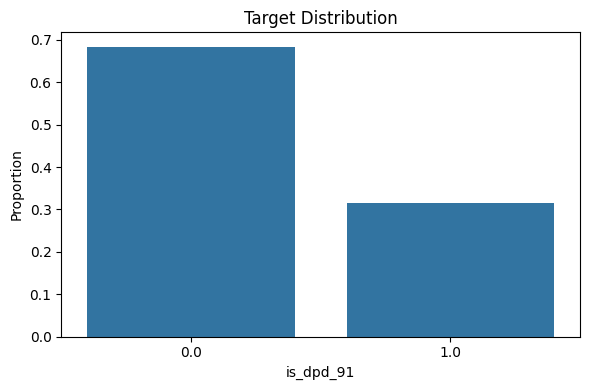

In [9]:
# ============================================================
# 3.4 Target Distribution
# ============================================================

target_distribution = (
    user_list.loc[labeled_mask, target]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / target_distribution["count"].sum()
)

display(target_distribution)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=target_distribution,
    x="target",
    y="percentage"
)

plt.title("Target Distribution")
plt.xlabel("is_dpd_91")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 3.5 Credit ID Audit
# ============================================================

credit_id = "credit_id"

total_rows = len(user_list)
unique_credits = user_list[credit_id].nunique()
duplicate_rows = total_rows - unique_credits

print(f"Total rows: {total_rows:,}")
print(f"Unique credit_id: {unique_credits:,}")
print(f"Rows beyond unique credit_id count: {duplicate_rows:,}")

print("\nDuplicated credit_id rows:")
print(f"{user_list[credit_id].duplicated(keep=False).sum():,}")

Total rows: 61,200
Unique credit_id: 46,516
Rows beyond unique credit_id count: 14,684

Duplicated credit_id rows:
27,289


In [13]:
# ============================================================
# 3.6 Credit ID Frequency
# ============================================================

credit_frequency = (
    user_list[credit_id]
    .value_counts()
    .rename("event_count")
)

print("Credit ID frequency distribution:")
display(credit_frequency.describe())

print("\nNumber of credits by event count:")
display(
    credit_frequency
    .value_counts()
    .sort_index()
    .head(20)
    .rename_axis("event_count")
    .reset_index(name="number_of_credits")
)

Credit ID frequency distribution:


count    46516.000000
mean         1.315676
std          0.559145
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: event_count, dtype: float64


Number of credits by event count:


,event_count,number_of_credits
0,1,33911
1,2,10685
2,3,1769
3,4,144
4,5,6
5,6,1


In [14]:
# ============================================================
# 3.7 Temporal Coverage
# ============================================================

print("created_month unique values:")
print(sorted(user_list["created_month"].dropna().unique()))

print("\nNumber of rows by created_month:")
display(
    user_list["created_month"]
    .value_counts()
    .sort_index()
    .rename_axis("created_month")
    .reset_index(name="row_count")
)

print("\ndate_dpd_31 range:")

date_dpd_31 = pd.to_datetime(user_list["date_dpd_31"], errors="coerce")

print("Minimum:", date_dpd_31.min())
print("Maximum:", date_dpd_31.max())
print("Missing:", date_dpd_31.isna().sum())

created_month unique values:
[np.int64(202512), np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604), np.int64(202605), np.int64(202606)]

Number of rows by created_month:


,created_month,row_count
0,202512,8796
1,202601,7846
2,202602,8733
3,202603,9775
4,202604,9263
5,202605,8943
6,202606,7844



date_dpd_31 range:
Minimum: 2025-12-16 00:00:00
Maximum: 2026-06-15 00:00:00
Missing: 0


In [15]:
# ============================================================
# 3.8 Missing Values Overview
# ============================================================

missing_summary = (
    user_list.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_rate"] = (
    missing_summary["missing_count"] / len(user_list)
)

missing_summary = (
    missing_summary
    .sort_values("missing_rate", ascending=False)
)

display(missing_summary)

,missing_count,missing_rate
avg_trx_amount_l7d,52655,0.860376
avg_trx_amount_l30d,41502,0.678137
avg_trx_amount_l60d,21144,0.345490
avg_trx_amount_l90d,20073,0.327990
app_recency_days,11522,0.188268
sessions_l7d,11522,0.188268
sessions_l30d,11522,0.188268
sessions_l60d,11522,0.188268
sessions_l90d,11522,0.188268
read_noti_l7d,11522,0.188268


## 4. Prediction Point and Feature Availability

Энэ асуудлын prediction point нь зээлдэгч 31 хоногийн хугацаа хэтрүүлсэн буюу `DPD31`-д хүрсэн мөч юм.

`data_description`-ийн дагуу `date_dpd_31` нь тухайн зээлдэгч DPD31-д хүрсэн яг огноог илэрхийлдэг бөгөөд `user_list`-ийн бусад feature-үүд энэ огноог Day 0 буюу prediction cutoff point болгон ашигладаг.

Иймээс model-д ашиглах feature нь prediction хийх мөчид мэдэгдэж байсан мэдээллээр хязгаарлагдах ёстой.

Энэ шалгалтын үндсэн зорилго нь:

1. Prediction хийхэд шууд ашиглах боломжгүй identifier болон time-related багануудыг тодорхойлох
2. Target-тэй шууд холбоотой эсвэл prediction point-оос хойших мэдээлэл ашигласан байж болзошгүй feature-үүдийг шалгах
3. Prediction dataset дээр ашиглах боломжгүй feature-үүдийг тодорхойлох

Feature exclusion хийхдээ зөвхөн missingness бус, тухайн feature-ийн утга болон мэдээлэл үүссэн хугацааг хамтад нь авч үзнэ.

In [16]:
# ============================================================
# 4.1 Feature Availability Audit
# ============================================================

feature_audit = pd.DataFrame({
    "feature": user_list.columns,
    "dtype": user_list.dtypes.astype(str).values,
    "missing_count": user_list.isna().sum().values,
    "missing_rate": user_list.isna().mean().values,
})

feature_audit["prediction_missing_count"] = (
    user_list.loc[unlabeled_mask].isna().sum().reindex(user_list.columns).values
)

feature_audit["prediction_missing_rate"] = (
    user_list.loc[unlabeled_mask].isna().mean()
    .reindex(user_list.columns)
    .values
)

display(
    feature_audit
    .sort_values("prediction_missing_rate", ascending=False)
)

,feature,dtype,missing_count,missing_rate,prediction_missing_count,prediction_missing_rate
38,number_change_cnt_l30d,float64,8463,0.138284,8463,1.000000
42,is_dpd_91,float64,8463,0.138284,8463,1.000000
25,avg_trx_amount_l7d,float64,52655,0.860376,8463,1.000000
37,is_unitel,float64,8463,0.138284,8463,1.000000
40,number_change_cnt_l90d,float64,8463,0.138284,8463,1.000000
39,number_change_cnt_l60d,float64,8463,0.138284,8463,1.000000
41,number_change_cnt,float64,8463,0.138284,8463,1.000000
26,avg_trx_amount_l30d,float64,41502,0.678137,8462,0.999882
28,avg_trx_amount_l90d,float64,20073,0.327990,8461,0.999764
27,avg_trx_amount_l60d,float64,21144,0.345490,8460,0.999646


In [17]:
# ============================================================
# 4.2 Features with Very High Missingness in Prediction Set
# ============================================================

prediction_availability = (
    feature_audit[
        [
            "feature",
            "prediction_missing_count",
            "prediction_missing_rate"
        ]
    ]
    .sort_values("prediction_missing_rate", ascending=False)
)

display(
    prediction_availability[
        prediction_availability["prediction_missing_rate"] >= 0.90
    ]
)

,feature,prediction_missing_count,prediction_missing_rate
38,number_change_cnt_l30d,8463,1.000000
42,is_dpd_91,8463,1.000000
25,avg_trx_amount_l7d,8463,1.000000
37,is_unitel,8463,1.000000
40,number_change_cnt_l90d,8463,1.000000
39,number_change_cnt_l60d,8463,1.000000
41,number_change_cnt,8463,1.000000
26,avg_trx_amount_l30d,8462,0.999882
28,avg_trx_amount_l90d,8461,0.999764
27,avg_trx_amount_l60d,8460,0.999646


In [18]:
# ============================================================
# 4.3 Identifier and Time-related Features
# ============================================================

identifier_time_features = [
    "credit_id",
    "created_month",
    "date_dpd_31"
]

display(
    feature_audit[
        feature_audit["feature"].isin(identifier_time_features)
    ]
)

,feature,dtype,missing_count,missing_rate,prediction_missing_count,prediction_missing_rate
0,created_month,int64,0,0.0,0,0.0
1,date_dpd_31,datetime64[ns],0,0.0,0,0.0
2,credit_id,int64,0,0.0,0,0.0


## 5. Missingness Pattern in Labeled vs Prediction Data

Prediction dataset дээр олон feature маш өндөр missing rate-тэй байгаа нь ажиглагдсан.

Гэхдээ өндөр missingness-ийг шууд feature exclusion хийх үндэслэл гэж үзэхгүй. Missing value нь тухайн мэдээлэл тухайн observation-д байхгүй байгааг илэрхийлэх бөгөөд энэ missingness өөрөө predictive information агуулж болох юм.

Иймээс эхлээд missingness нь dataset-ийн аль хэсэгт, ялангуяа аль `created_month`-д төвлөрч байгааг шалгана.

Энэ нь:

- Prediction dataset-ийн бүтэц
- Feature availability-ийн өөрчлөлт
- Missingness-ийн temporal pattern

зэргийг ойлгоход ашиглагдана.

In [19]:
# ============================================================
# 5.1 Labeled vs Prediction Rows by Month
# ============================================================

month_summary = (
    user_list.assign(
        data_group=np.where(
            user_list[target].isna(),
            "Prediction",
            "Labeled"
        )
    )
    .groupby(["created_month", "data_group"])
    .size()
    .unstack(fill_value=0)
)

month_summary["Total"] = month_summary.sum(axis=1)

display(month_summary)

data_group,Labeled,Prediction,Total
created_month,,,
202512,8657,139,8796
202601,7714,132,7846
202602,8630,103,8733
202603,9671,104,9775
202604,9170,93,9263
202605,8895,48,8943
202606,0,7844,7844


In [20]:
# ============================================================
# 5.2 Prediction Share by Month
# ============================================================

month_summary["Prediction Share"] = (
    month_summary.get("Prediction", 0)
    / month_summary["Total"]
)

display(
    month_summary[
        ["Total", "Labeled", "Prediction", "Prediction Share"]
    ]
)

data_group,Total,Labeled,Prediction,Prediction Share
created_month,,,,
202512,8796,8657,139,0.015803
202601,7846,7714,132,0.016824
202602,8733,8630,103,0.011794
202603,9775,9671,104,0.010639
202604,9263,9170,93,0.010040
202605,8943,8895,48,0.005367
202606,7844,0,7844,1.000000


In [21]:
# ============================================================
# 5.3 Feature Availability by Month
# ============================================================

availability_features = [
    "limit_dpd31",
    "balance_dpd31",
    "invoiced_unpaid_amt",
    "ostype",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "sessions_l7d",
    "read_noti_l30d",
    "gender",
    "has_changed_phone",
    "is_unitel",
]

availability_by_month = (
    user_list
    .groupby("created_month")[availability_features]
    .apply(lambda x: x.notna().mean())
)

display(availability_by_month.round(3))

,limit_dpd31,balance_dpd31,invoiced_unpaid_amt,ostype,trx_l7d,trx_l30d,trx_l60d,trx_l90d,sessions_l7d,read_noti_l30d,gender,has_changed_phone,is_unitel
created_month,,,,,,,,,,,,,
202512,1.0,1.0,1.0,0.984,0.883,0.883,0.883,0.883,0.912,0.912,0.984,0.984,0.984
202601,1.0,1.0,1.0,0.983,0.876,0.876,0.876,0.876,0.908,0.908,0.983,0.983,0.983
202602,1.0,1.0,1.0,0.988,0.962,0.962,0.962,0.962,0.936,0.936,0.988,0.988,0.988
202603,0.0,0.0,1.0,0.990,0.976,0.976,0.976,0.976,0.940,0.940,0.990,0.990,0.989
202604,1.0,1.0,1.0,0.990,0.982,0.982,0.982,0.982,0.941,0.941,0.990,0.990,0.990
202605,1.0,1.0,1.0,0.995,0.988,0.988,0.988,0.988,0.945,0.945,0.995,0.995,0.995
202606,1.0,1.0,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [22]:
# ============================================================
# 5.4 Feature Availability: Labeled vs Prediction
# ============================================================

availability_comparison = pd.DataFrame({
    "Labeled_Availability": (
        user_list.loc[labeled_mask, availability_features]
        .notna()
        .mean()
    ),
    "Prediction_Availability": (
        user_list.loc[unlabeled_mask, availability_features]
        .notna()
        .mean()
    )
})

availability_comparison["Availability_Drop"] = (
    availability_comparison["Labeled_Availability"]
    - availability_comparison["Prediction_Availability"]
)

display(
    availability_comparison
    .sort_values("Availability_Drop", ascending=False)
    .round(4)
)

,Labeled_Availability,Prediction_Availability,Availability_Drop
is_unitel,1.0000,0.0000,1.0000
gender,1.0000,0.0007,0.9993
has_changed_phone,1.0000,0.0007,0.9993
ostype,1.0000,0.0007,0.9993
trx_l7d,0.9579,0.0005,0.9575
trx_l60d,0.9579,0.0005,0.9575
trx_l90d,0.9579,0.0005,0.9575
trx_l30d,0.9579,0.0005,0.9575
sessions_l7d,0.9419,0.0005,0.9414
read_noti_l30d,0.9419,0.0005,0.9414


## 6. Feature Availability and Leakage Decision

Prediction dataset нь 2026 оны 6-р сарын observation-уудаас бүрдэж байгаа бөгөөд энэ сарын бүх 7,844 observation target-гүй байна.

Feature availability-ийн audit-аар transaction, session, notification, demographic болон number-change төрлийн олон feature 2026 оны prediction data дээр бараг бүрэн missing байгааг харуулсан.

Иймээс model training үед labeled data дээр available боловч final prediction data дээр байхгүй feature-үүдийг ашиглах нь бодит deployment нөхцөлтэй нийцэхгүй.

Мөн `date_dpd_31` нь prediction cutoff буюу Day 0 гэж тодорхойлогдсон. Иймээс identifier болон cutoff information-ийг model feature болгон ашиглахгүй.

`total_payment_amt` нь source-ийн тайлбарт reporting period-ийн нийт төлөлт гэж тодорхойлогдсон боловч тухайн reporting period нь prediction cutoff-оос өмнөх эсэх тодорхойгүй байна. Иймээс Data Leakage үүсгэх боломжтой гэж үзэн primary model-оос хасна.

Эцсийн feature selection-ийн үндсэн зарчим:

1. Prediction point дээр мэдээлэл боломжтой байх
2. Final prediction dataset дээр feature availability хангалттай байх
3. Target болон future outcome-той шууд холбоотой мэдээлэл агуулаагүй байх
4. Identifier болон purely temporal fields-ийг model feature болгон ашиглахгүй байх

In [23]:
# ============================================================
# 6.1 Define Feature Groups
# ============================================================

identifier_features = [
    "credit_id"
]

temporal_features = [
    "created_month",
    "date_dpd_31"
]

potential_leakage_features = [
    "total_payment_amt"
]

prediction_available_features = [
    "limit_dpd31",
    "balance_dpd31",
    "limit_ondue",
    "balance_ondue",
    "invoiced_unpaid_amt"
]

excluded_features = (
    identifier_features
    + temporal_features
    + potential_leakage_features
)

print("Prediction-available candidate features:")
for feature in prediction_available_features:
    print(f"- {feature}")

print("\nExcluded features:")
for feature in excluded_features:
    print(f"- {feature}")

Prediction-available candidate features:
- limit_dpd31
- balance_dpd31
- limit_ondue
- balance_ondue
- invoiced_unpaid_amt

Excluded features:
- credit_id
- created_month
- date_dpd_31
- total_payment_amt


In [24]:
# ============================================================
# 6.2 Verify Final Candidate Feature Availability
# ============================================================

candidate_availability = pd.DataFrame({
    "feature": prediction_available_features,
    "labeled_availability": [
        user_list.loc[labeled_mask, feature].notna().mean()
        for feature in prediction_available_features
    ],
    "prediction_availability": [
        user_list.loc[unlabeled_mask, feature].notna().mean()
        for feature in prediction_available_features
    ]
})

candidate_availability["prediction_missing_rate"] = (
    1 - candidate_availability["prediction_availability"]
)

display(candidate_availability.round(4))

,feature,labeled_availability,prediction_availability,prediction_missing_rate
0,limit_dpd31,0.8166,0.9877,0.0123
1,balance_dpd31,0.8166,0.9877,0.0123
2,limit_ondue,1.0000,1.0000,0.0000
3,balance_ondue,1.0000,1.0000,0.0000
4,invoiced_unpaid_amt,1.0000,1.0000,0.0000


In [25]:
# ============================================================
# 6.3 Verify Excluded Feature Availability
# ============================================================

excluded_audit = pd.DataFrame({
    "feature": excluded_features,
    "prediction_availability": [
        user_list.loc[unlabeled_mask, feature].notna().mean()
        for feature in excluded_features
    ],
    "reason": [
        "Identifier",
        "Temporal split variable",
        "Prediction cutoff variable",
        "Potential post-cutoff / reporting-period leakage"
    ]
})

display(excluded_audit.round(4))

,feature,prediction_availability,reason
0,credit_id,1.0,Identifier
1,created_month,1.0,Temporal split variable
2,date_dpd_31,1.0,Prediction cutoff variable
3,total_payment_amt,1.0,Potential post-cutoff / reporting-period leakage


In [26]:
# ============================================================
# 6.4 Final Raw Feature Set
# ============================================================

final_raw_features = prediction_available_features.copy()

print(f"Number of final raw features: {len(final_raw_features)}")

print("\nFinal raw features:")
for i, feature in enumerate(final_raw_features, 1):
    print(f"{i:02d}. {feature}")

Number of final raw features: 5

Final raw features:
01. limit_dpd31
02. balance_dpd31
03. limit_ondue
04. balance_ondue
05. invoiced_unpaid_amt


## 6.1 Investigation of `ostype` Availability

Өмнөх clean benchmark pipeline-д `ostype` feature ашиглагдсан боловч шинэ audit-аар final prediction dataset дээр `ostype`-ийн availability маш бага буюу зөвхөн 6 observation байгааг илрүүлсэн.

Иймээс `ostype`-ийг шууд include/exclude хийхээс өмнө:

- prediction dataset дээр ямар утгууд байгаа,
- аль `created_month`-д байгаа,
- labeled болон prediction data-ийн availability хэр ялгаатай,
- missingness нь системийн тодорхой бүтэцтэй холбоотой эсэх

зэргийг шалгана.

Энэхүү шалгалтын дараа `ostype`-ийг final feature set-д оруулах эсэхийг эцэслэнэ.

In [27]:
# ============================================================
# 6.1.1 Inspect ostype values in prediction data
# ============================================================

ostype_prediction = (
    user_list.loc[unlabeled_mask, ["credit_id", "created_month", "date_dpd_31", "ostype"]]
    .copy()
)

print("Prediction rows with non-missing ostype:")
display(
    ostype_prediction[ostype_prediction["ostype"].notna()]
)

Prediction rows with non-missing ostype:


,credit_id,created_month,date_dpd_31,ostype
52915,2270103,202602,2026-02-15,1.0
53207,2238839,202601,2026-01-15,1.0
54275,2484959,202601,2026-01-15,2.0
57277,2397647,202603,2026-03-18,2.0
57462,2484959,202603,2026-03-18,2.0
58741,2270103,202603,2026-03-18,1.0


In [28]:
# ============================================================
# 6.1.2 Ostype availability by month
# ============================================================

ostype_by_month = (
    user_list
    .groupby(["created_month"])
    .agg(
        total_rows=("ostype", "size"),
        available_ostype=("ostype", "count")
    )
)

ostype_by_month["availability_rate"] = (
    ostype_by_month["available_ostype"]
    / ostype_by_month["total_rows"]
)

display(ostype_by_month)

,total_rows,available_ostype,availability_rate
created_month,,,
202512,8796,8657,0.984197
202601,7846,7716,0.983431
202602,8733,8631,0.988320
202603,9775,9674,0.989668
202604,9263,9170,0.989960
202605,8943,8895,0.994633
202606,7844,0,0.000000


In [29]:
# ============================================================
# 6.1.3 Ostype value distribution
# ============================================================

print("Labeled ostype distribution:")
display(
    user_list.loc[labeled_mask, "ostype"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPrediction ostype distribution:")
display(
    user_list.loc[unlabeled_mask, "ostype"]
    .value_counts(dropna=False)
    .sort_index()
)

Labeled ostype distribution:


ostype
1.0    26085
2.0    25770
3.0      882
Name: count, dtype: int64


Prediction ostype distribution:


ostype
1.0       3
2.0       3
NaN    8457
Name: count, dtype: int64